# Delamanid ablation comparison

Five stability-selection runs on CMM-logistic with `max_parents=4`, `k_max=6`, `min_cluster_count=4`, 100 subsamples at 80%. Conditions differ only in which covariates are included and which edges into `dlm_mic` are forbidden:

1. `baseline`: mutation features only
2. `with_lineage`: + one-hot lineage (`lineage_2`, `lineage_4`; minor lineages merged below 5 samples)
3. `with_lineage_and_type`: + `type_beyond_MDR` (exogenous binary covariate)
4. `with_lineage_forbid_to_mic`: lineage included, `lineage -> dlm_mic` forbidden
5. `with_lineage_and_type_forbid_to_mic`: lineage + type included, `type -> dlm_mic` forbidden

Goal: identify which `mutation -> dlm_mic` edges are stable under progressive confounder adjustment.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parents[2]))

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

RESULTS = Path.cwd().parents[2] / 'results' / 'subsampling' / 'tb_subsampling_dlm_mp4_k6_mcc4'
CONDITIONS = ['baseline', 'with_lineage', 'with_lineage_and_type', 'with_lineage_forbid_to_mic', 'with_lineage_and_type_forbid_to_mic']
SHORT = {
    'baseline': 'baseline',
    'with_lineage': '+lineage',
    'with_lineage_and_type': '+lineage+type',
    'with_lineage_forbid_to_mic': 'forbid lin->MIC',
    'with_lineage_and_type_forbid_to_mic': 'forbid type->MIC',
}

edges = {c: pd.read_csv(RESULTS / c / 'edge_stability.csv') for c in CONDITIONS}
kdist = {c: pd.read_csv(RESULTS / c / 'per_node_k.csv') for c in CONDITIONS}

## dlm_mic mixture order stable at k=6

Mode k for `dlm_mic` is 6 across all five conditions, with k=6 selected in 43-50% of runs. Restricting edges or adding parents shifts a few runs to k=5. `k_max=6` is a sufficient ceiling.

In [2]:
rows = []
for c in CONDITIONS:
    row = kdist[c][kdist[c]['feature'] == 'dlm_mic'].iloc[0]
    rows.append({'condition': SHORT[c], 'mode_k': int(row['mode_k']), 'k=6 share': int(row['k6_count']) / 100, 'mean_k': round(float(row['mean_k']), 2)})
pd.DataFrame(rows)

,condition,mode_k,k=6 share,mean_k
0,baseline,6,0.49,5.35
1,+lineage,6,0.50,5.31
2,+lineage+type,6,0.45,5.21
3,forbid lin->MIC,6,0.43,5.22
4,forbid type->MIC,6,0.47,5.30


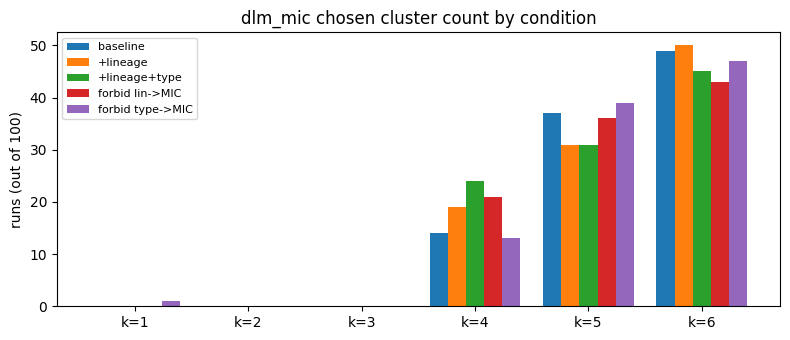

In [3]:
fig, ax = plt.subplots(figsize=(8, 3.5))
k_cols_template = ['k1_count', 'k2_count', 'k3_count', 'k4_count', 'k5_count', 'k6_count']
x = np.arange(6)
n_cond = len(CONDITIONS)
width = 0.8 / n_cond
for i, c in enumerate(CONDITIONS):
    row = kdist[c][kdist[c]['feature'] == 'dlm_mic'].iloc[0]
    counts = [int(row[col]) if col in row.index else 0 for col in k_cols_template]
    ax.bar(x + i * width, counts, width, label=SHORT[c])
ax.set_xticks(x + (n_cond - 1) / 2 * width)
ax.set_xticklabels(['k=1', 'k=2', 'k=3', 'k=4', 'k=5', 'k=6'])
ax.set_ylabel('runs (out of 100)')
ax.set_title('dlm_mic chosen cluster count by condition')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Mutation -> dlm_mic frequencies across conditions

Each row is a mutation feature. Columns give the selection frequency of the `mutation -> dlm_mic` edge under each condition. A stable edge should hold up under both lineage and type adjustment.

In [4]:
MIN_ELIGIBLE = 50

def freq_to_mic(df, source):
    sub = df[(df['target'] == 'dlm_mic') & (df['source'] == source) & (df['n_eligible'] >= MIN_ELIGIBLE)]
    return float(sub['frequency'].iloc[0]) if len(sub) else 0.0

variants = sorted({s for c in CONDITIONS for s in edges[c]['source'].unique()} - {'lineage_2', 'lineage_4', 'type_beyond_MDR', 'fgd1_Lys270Met'})
table = pd.DataFrame({SHORT[c]: [freq_to_mic(edges[c], v) for v in variants] for c in CONDITIONS}, index=variants)
table = table.sort_values(SHORT['with_lineage_forbid_to_mic'], ascending=False)
table.round(2)

,baseline,+lineage,+lineage+type,forbid lin->MIC,forbid type->MIC
pepq_Ala87Gly,0.27,0.51,0.41,0.61,0.36
mmpl5_Asp767Asn,0.38,0.08,0.06,0.35,0.08
rv1979c_C*135G,0.55,0.39,0.37,0.33,0.44
rv0678_G*128C,0.30,0.06,0.19,0.26,0.16
mmpl5_Thr794Ile,0.14,0.02,0.00,0.11,0.01
fgd1_G*357C,0.17,0.05,0.09,0.07,0.06
mmpl5_Ile948Val,0.00,0.01,0.00,0.00,0.00
fgd1_Phe320Phe,0.06,0.00,0.00,0.00,0.00


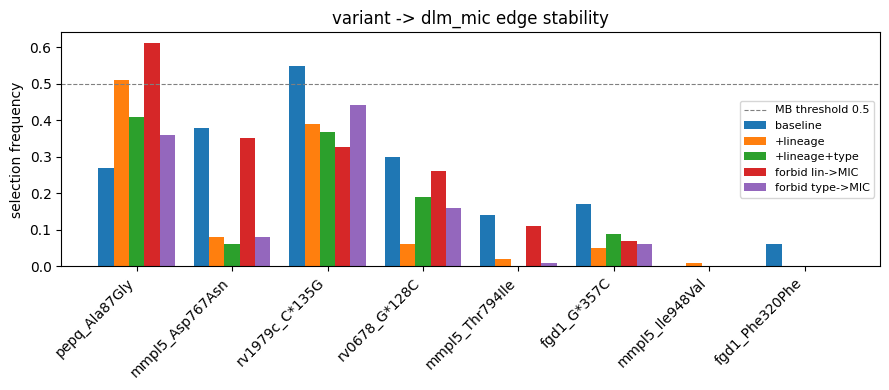

In [5]:
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(table))
n_cond = len(CONDITIONS)
width = 0.8 / n_cond
for i, c in enumerate(CONDITIONS):
    ax.bar(x + i * width, table[SHORT[c]].values, width, label=SHORT[c])
ax.axhline(0.5, color='grey', linestyle='--', linewidth=0.8, label='MB threshold 0.5')
ax.set_xticks(x + (n_cond - 1) / 2 * width)
ax.set_xticklabels(table.index, rotation=45, ha='right')
ax.set_ylabel('selection frequency')
ax.set_title('variant -> dlm_mic edge stability')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Only pepq_Ala87Gly increases with lineage

Most mutation -> MIC frequencies drop sharply when lineage is added (`rv1979c`, `mmpl5_Asp767Asn`, `rv0678`, `fgd1_G*357C`, `mmpl5_Thr794Ile`): their baseline signal flows through lineage. `pepq_Ala87Gly` is the exception: 0.27 -> 0.51 -> 0.61 across `baseline`, `+lineage`, `forbid lin->MIC`. The type-confounding analysis below walks this back.

## Lineage absorbs mutation-mutation co-variation

Some mutation-to-mutation edges in `baseline` are lineage-driven dependencies (mutations co-occur because they share a lineage). Adding lineage redirects the edge to its source.

Example: `mmpl5_Thr794Ile -> fgd1_Phe320Phe` was 78/100 in baseline. With lineage in, that edge vanishes and `lineage_4 -> mmpl5_Thr794Ile` and `lineage_4 -> fgd1_Phe320Phe` both saturate at 99/100.

Mutation-to-mutation edges that survive lineage adjustment are more likely to reflect direct dependence.


In [6]:
df = edges['with_lineage']
lineage_out = df[df['source'].isin(['lineage_2', 'lineage_4']) & (df['n_eligible'] >= MIN_ELIGIBLE)].sort_values('frequency', ascending=False)
lineage_out[['source', 'target', 'frequency']].round(2).reset_index(drop=True)

,source,target,frequency
0,lineage_4,mmpl5_Thr794Ile,0.99
1,lineage_4,fgd1_Phe320Phe,0.99
2,lineage_2,mmpl5_Asp767Asn,0.95
3,lineage_2,rv0678_G*128C,0.84
4,lineage_2,dlm_mic,0.52
5,lineage_4,fgd1_G*357C,0.46
6,lineage_4,rv1979c_C*135G,0.45
7,lineage_2,rv1979c_C*135G,0.25
8,lineage_2,pepq_Ala87Gly,0.18
9,lineage_4,dlm_mic,0.12


## type_beyond_MDR edges

`type_beyond_MDR` is an exogenous binary covariate: incoming edges are forbidden, outgoing edges are allowed. 52/100 samples have type=1.

Edges out of type:
- `type -> pepq_Ala87Gly`: 0.35
- `type -> dlm_mic`: 0.27

Sampling skews toward type=1, so type acts as a collider between any of its children. Conditioning on it without forbidding `type -> dlm_mic` can inflate `pepq -> dlm_mic`. The next section forbids the edge and measures the redistribution.


In [7]:
df = edges['with_lineage_and_type']
type_out = df[(df['source'] == 'type_beyond_MDR') & (df['n_eligible'] >= MIN_ELIGIBLE)].sort_values('frequency', ascending=False)
type_out[['source', 'target', 'count', 'n_eligible', 'frequency']].round(3).reset_index(drop=True)

,source,target,count,n_eligible,frequency
0,type_beyond_MDR,pepq_Ala87Gly,18,52,0.346
1,type_beyond_MDR,dlm_mic,14,52,0.269
2,type_beyond_MDR,rv1979c_C*135G,1,51,0.020
3,type_beyond_MDR,fgd1_G*357C,1,52,0.019


## Forbidding type -> dlm_mic redistributes signal

Blocking `type -> dlm_mic` forces the variance type was claiming on MIC to flow elsewhere. Between `+lineage+type` and `forbid type->MIC`:

- `type -> pepq_Ala87Gly`: 0.35 -> 0.46
- `rv1979c_C*135G -> dlm_mic`: 0.37 -> 0.44
- `pepq_Ala87Gly -> dlm_mic`: 0.41 -> 0.36
- `lineage_2 -> dlm_mic`: 0.55 (unchanged)

`pepq_Ala87Gly -> dlm_mic` across `+lineage`, `+lineage+type`, `forbid type->MIC` is 0.51 -> 0.41 -> 0.36: monotonic decline as the type pathway is progressively closed. Under the strictest adjustment, no mutation passes the 0.5 stability threshold.

In [8]:
allow = edges['with_lineage_and_type'].set_index(['source', 'target'])['frequency']
forbid = edges['with_lineage_and_type_forbid_to_mic'].set_index(['source', 'target'])['frequency']
key_edges = [
    ('lineage_2', 'dlm_mic'),
    ('type_beyond_MDR', 'dlm_mic'),
    ('type_beyond_MDR', 'pepq_Ala87Gly'),
    ('pepq_Ala87Gly', 'dlm_mic'),
    ('rv1979c_C*135G', 'dlm_mic'),
]
pd.DataFrame({
    'edge': [f'{s} -> {t}' for s, t in key_edges],
    '+lineage+type': [round(allow.get((s, t), 0.0), 2) for s, t in key_edges],
    'forbid type->MIC': [round(forbid.get((s, t), 0.0), 2) for s, t in key_edges],
})

,edge,+lineage+type,forbid type->MIC
0,lineage_2 -> dlm_mic,0.55,0.55
1,type_beyond_MDR -> dlm_mic,0.27,0.00
2,type_beyond_MDR -> pepq_Ala87Gly,0.35,0.46
3,pepq_Ala87Gly -> dlm_mic,0.41,0.36
4,rv1979c_C*135G -> dlm_mic,0.37,0.44


## Takeaways

**Stability criterion.** A `mutation -> dlm_mic` edge is credible if its frequency holds up across `with_lineage` (honest model) and both stress tests: `forbid lin->MIC` and `forbid type->MIC`.

**Candidates:**
1. `pepq_Ala87Gly`: 0.51 -> 0.41 -> 0.36 under progressive type adjustment (monotonic decline). The 0.61 in `forbid lin->MIC` is the opposite stress: `lineage_2`'s MIC signal is rerouted through whichever mutation co-occurs with it, and `lineage_2 -> pepq` is 0.18. Neither side passes 0.5 cleanly.
2. `rv1979c_C*135G`: 0.55 -> 0.39 -> 0.37 -> 0.44 -> 0.33 across `baseline`, `+lin`, `+type`, `forbid type`, `forbid lin`. Mixed.
3. `mmpl5_Asp767Asn`: 0.08 in `with_lineage`, 0.35 in `forbid lin->MIC`. `lineage_2 -> mmpl5_Asp767Asn = 0.95`, so `forbid lin->MIC` just reroutes `lineage_2`'s MIC signal through it. Artifact.

**Robust finding.** `lineage_2 -> dlm_mic` at 0.52-0.55 across all five conditions, the only above-threshold MIC parent. Under the strictest adjustment no mutation passes 0.5.